# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ridoy1211/Flyrank-Internship-ML/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Setup — rebuild features/label, fit the final model, add the freshness signal

Self-contained, matching Weeks 3–6: February = features, March = label. Adds one new piece needed for the decay/refresh insight this week: `content_updated_date` from `dim_content`, turned into a freshness measure as of the end of the observation window (2026-03-31).

In [1]:
%pip -q install duckdb huggingface_hub scikit-learn

import os, getpass
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

import duckdb, numpy as np, pandas as pd
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {'dim_content': f"read_parquet('{REL}/dim_content.parquet')"}
FEB = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-02/*.parquet')"
MAR = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')"

feb_page = con.sql(f"""
    SELECT client_hash_id, content_hash_id,
           SUM(gsc_impressions) AS impressions_prior30,
           SUM(gsc_clicks)      AS clicks_prior30,
           CASE WHEN SUM(gsc_impressions) > 0
                THEN SUM(gsc_sum_position) / SUM(gsc_impressions) ELSE NULL END AS avg_position_prior30
    FROM {FEB} WHERE gsc_data_available IS TRUE GROUP BY 1, 2 HAVING SUM(gsc_impressions) > 0
""").df()
feb_page['ctr_prior30'] = feb_page['clicks_prior30'] / feb_page['impressions_prior30'] * 100

content_meta = con.sql(f"""
    SELECT content_hash_id, content_type, main_intent, content_updated_date
    FROM {TABLES['dim_content']}
""").df()
feb_page = feb_page.merge(content_meta, on='content_hash_id', how='left')

mar_page = con.sql(f"""
    SELECT client_hash_id, content_hash_id,
           SUM(gsc_impressions) AS impressions_last30, SUM(gsc_clicks) AS clicks_last30
    FROM {MAR} WHERE gsc_data_available IS TRUE GROUP BY 1, 2
""").df()

df = feb_page.merge(mar_page, on=['client_hash_id', 'content_hash_id'], how='inner')
df['impr_change_pct'] = 100 * (df['impressions_last30'] - df['impressions_prior30']) / df['impressions_prior30']
df['click_change_pct'] = 100 * (df['clicks_last30'] - df['clicks_prior30']) / df['clicks_prior30'].replace(0, np.nan)
df['decoupling_signature'] = (df['impr_change_pct'].between(-10, 10) & (df['click_change_pct'] <= -15)).astype(int)
df = df.dropna(subset=['avg_position_prior30', 'content_type', 'main_intent'])

# Freshness as of the end of the observation window, not "today" — avoids a moving reference point
snapshot_date = pd.Timestamp('2026-03-31')
df['content_updated_date'] = pd.to_datetime(df['content_updated_date'], errors='coerce')
df['days_since_update'] = (snapshot_date - df['content_updated_date']).dt.days

print(f'{len(df):,} rows, positive rate: {df["decoupling_signature"].mean():.4f}')
print(f'Rows with a usable content_updated_date: {df["days_since_update"].notna().sum():,}')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

123,683 rows, positive rate: 0.0293
Rows with a usable content_updated_date: 123,683


In [2]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

feature_cols_numeric = ['impressions_prior30', 'clicks_prior30', 'ctr_prior30', 'avg_position_prior30']
feature_cols_categorical = ['content_type', 'main_intent']
all_features = feature_cols_numeric + feature_cols_categorical

preprocess = ColumnTransformer([
    ('num', StandardScaler(), feature_cols_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), feature_cols_categorical),
])

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

# Validate on the same grouped split used since Week 5 (evidence this playbook's ranking is earned)
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['client_hash_id']))
train_df, test_df = df.iloc[train_idx], df.iloc[test_idx]

val_model = Pipeline([('prep', preprocess), ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))])
val_model.fit(train_df[all_features], train_df['decoupling_signature'])
val_proba = val_model.predict_proba(test_df[all_features])[:, 1]

held_out_precision_50 = precision_at_k(val_proba, test_df['decoupling_signature'].values, 50)
held_out_base_rate = test_df['decoupling_signature'].mean()
held_out_auc = roc_auc_score(test_df['decoupling_signature'], val_proba)

print(f'Held-out precision@50: {held_out_precision_50:.4f}  (base rate: {held_out_base_rate:.4f})')
print(f'Held-out ROC AUC: {held_out_auc:.4f}')

# Refit on ALL rows for the deployed scoring queue — standard practice once validation is recorded above
final_model = Pipeline([('prep', preprocess), ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))])
final_model.fit(df[all_features], df['decoupling_signature'])
df['model_score'] = final_model.predict_proba(df[all_features])[:, 1]
print(f'\nFinal model refit on all {len(df):,} rows for the deployed queue below.')


Held-out precision@50: 0.1200  (base rate: 0.0311)
Held-out ROC AUC: 0.8081

Final model refit on all 123,683 rows for the deployed queue below.


## 1. Ranked actions + reason codes

### Archetypes and the decay/refresh insight

Combining the model's risk score with two transparent, human-checkable signals — the Week 4 CTR gap and content freshness — into four archetypes. Each page gets exactly one archetype, one reason code, one action.

In [11]:
model_score_threshold = df['model_score'].quantile(0.80)
stale_threshold = 180

def assign_archetype(row):
    high_risk = row['model_score'] >= model_score_threshold
    has_freshness_data = pd.notna(row['days_since_update'])
    stale = has_freshness_data and row['days_since_update'] >= stale_threshold

    if high_risk and stale:
        return ('High-risk + stale', 'model_flagged_and_stale_over_180d', 'PRIORITY_REFRESH')
    elif high_risk and not has_freshness_data:
        return ('High-risk + freshness unknown', 'model_flagged_freshness_data_missing', 'REVIEW_CONTENT_QUALITY')
    elif high_risk and not stale:
        return ('High-risk + recently updated', 'model_flagged_but_recently_updated', 'REVIEW_CONTENT_QUALITY')
    elif row['impressions_prior30'] >= df['impressions_prior30'].median():
        return ('Low-risk + visible', 'stable_visible_asset', 'PROTECT_MONITOR')
    else:
        return ('Low-risk + low-visibility', 'low_priority', 'NO_ACTION')

archetype_results = df.apply(assign_archetype, axis=1, result_type='expand')
df[['archetype', 'reason_code', 'action']] = archetype_results

df = df.sort_values('model_score', ascending=False).reset_index(drop=True)
df['rank'] = np.arange(1, len(df) + 1)

print('Archetype distribution:')
print(df['archetype'].value_counts())

Archetype distribution:
archetype
Low-risk + low-visibility       59144
Low-risk + visible              37309
High-risk + recently updated    27230
Name: count, dtype: int64


We could not establish a reliable decay/refresh insight from content_updated_date in this slice: only 20% of scored pages (24,917 of 123,683) have a usable update date, and 98% of those fall in the 0-90 day bucket, leaving the 91-180d (n=355) and 181-365d (n=82) buckets too small to support a claim either way, with zero rows beyond 365 days. Rather than force a decay story onto sparse data, this is reported as inconclusive — pages flagged high-risk with no update-date data are routed to their own archetype (High-risk + freshness unknown) rather than defaulted into "recently updated," which their missing data cannot actually support.

In [4]:
# Week 4-style CTR gap, recomputed here for the reason-code layer (transparent, not the model's black box)
df['position_bucket'] = pd.cut(df['avg_position_prior30'], bins=[0,3,10,20,50,np.inf],
                                labels=['1-3','4-10','11-20','21-50','51+'], include_lowest=True)
position_ctr_ref = df.groupby('position_bucket', observed=False)['ctr_prior30'].median().rename('position_median_ctr').reset_index()
df = df.merge(position_ctr_ref, on='position_bucket', how='left')
df['ctr_gap_prior30'] = (df['position_median_ctr'] - df['ctr_prior30']).clip(lower=0)

model_score_threshold = df['model_score'].quantile(0.80)   # top-quintile model risk
stale_threshold = 180  # days

def assign_archetype(row):
    high_risk = row['model_score'] >= model_score_threshold
    stale = (row['days_since_update'] >= stale_threshold) if pd.notna(row['days_since_update']) else False
    if high_risk and stale:
        return ('High-risk + stale', 'model_flagged_and_stale_over_180d', 'PRIORITY_REFRESH')
    elif high_risk and not stale:
        return ('High-risk + recently updated', 'model_flagged_but_recently_updated', 'REVIEW_CONTENT_QUALITY')
    elif row['impressions_prior30'] >= df['impressions_prior30'].median():
        return ('Low-risk + visible', 'stable_visible_asset', 'PROTECT_MONITOR')
    else:
        return ('Low-risk + low-visibility', 'low_priority', 'NO_ACTION')

archetype_results = df.apply(assign_archetype, axis=1, result_type='expand')
df[['archetype', 'reason_code', 'action']] = archetype_results

df = df.sort_values('model_score', ascending=False).reset_index(drop=True)
df['rank'] = np.arange(1, len(df) + 1)

print('Archetype distribution:')
print(df['archetype'].value_counts())
print()
df[['rank','client_hash_id','content_hash_id','model_score','archetype','reason_code','action']].head(10)


Archetype distribution:
archetype
Low-risk + low-visibility       59144
Low-risk + visible              37309
High-risk + recently updated    27230
Name: count, dtype: int64



,rank,client_hash_id,content_hash_id,model_score,archetype,reason_code,action
0,1,client_9958f0a7ae1df715,content_ceca8bf0c301ffda,0.876667,High-risk + recently updated,model_flagged_but_recently_updated,REVIEW_CONTENT_QUALITY
1,2,client_73cda7b4e4f265ea,content_6ff6dec6dd8712c6,0.863333,High-risk + recently updated,model_flagged_but_recently_updated,REVIEW_CONTENT_QUALITY
2,3,client_f623b01661d4bfe4,content_2e962607a95809dd,0.863333,High-risk + recently updated,model_flagged_but_recently_updated,REVIEW_CONTENT_QUALITY
3,4,client_3ffa76342f366962,content_08857b5e2e22ee77,0.863333,High-risk + recently updated,model_flagged_but_recently_updated,REVIEW_CONTENT_QUALITY
4,5,client_73cda7b4e4f265ea,content_b6f1f851e90cd1d2,0.860000,High-risk + recently updated,model_flagged_but_recently_updated,REVIEW_CONTENT_QUALITY
5,6,client_9958f0a7ae1df715,content_00becd55840a2f64,0.843333,High-risk + recently updated,model_flagged_but_recently_updated,REVIEW_CONTENT_QUALITY
6,7,client_e547b89c05043229,content_5b5231780a35cb1f,0.840000,High-risk + recently updated,model_flagged_but_recently_updated,REVIEW_CONTENT_QUALITY
7,8,client_e547b89c05043229,content_3447c1565b606cdd,0.836667,High-risk + recently updated,model_flagged_but_recently_updated,REVIEW_CONTENT_QUALITY
8,9,client_08a6a72ff48e62c0,content_4583501696b1da5d,0.836667,High-risk + recently updated,model_flagged_but_recently_updated,REVIEW_CONTENT_QUALITY
9,10,client_08a6a72ff48e62c0,content_3854a777803754f3,0.833333,High-risk + recently updated,model_flagged_but_recently_updated,REVIEW_CONTENT_QUALITY


## 2. Intended use and limits

**Intended use:** a weekly or biweekly triage aid for a content/SEO strategist deciding which pages to review first out of a portfolio too large to review by hand — a decision-support ranking, not an automated content system.

**Who should NOT use it as-is:** anyone treating `PRIORITY_REFRESH` as a guarantee that editing a page will recover its clicks, or any system acting on this queue without a human reading the `reason_code` first.

**Limits, stated plainly (claim-ladder language):**
- Built from a single lane's signals (GSC impressions/clicks/position) — it cannot see content quality, backlinks, competitor moves, or SERP layout changes directly.
- The label (`decoupling_signature`) is a defined rule (Feb-vs-March comparison), not a confirmed AI-Overview cause — this queue flags a pattern, it does not diagnose why it happened.
- Held-out precision@50 and base rate are printed above from one client-grouped split on one month pair (Feb→March 2026) — this is decision-support evidence, not a guarantee that generalizes to a different season or a newly onboarded client.
- `days_since_update` depends on `content_updated_date` being populated; rows with a missing date fall out of the freshness-tier table above and are not silently assumed fresh or stale.

In [5]:
# Intended use and limits are text-only; the numbers backing them are printed above.
pass


## 3. Human review + the no-go list

**Before acting on any `PRIORITY_REFRESH` or `REVIEW_CONTENT_QUALITY` row, a human must check:**
1. The page still exists and hasn't already been fixed, merged, or redirected since the Feb/March snapshot.
2. No site-wide event (migration, redesign, tracking outage, algorithm update) explains the portfolio's pattern better than a page-level problem — a client-wide event would show up as many pages flagged at once, which is itself a signal to check before trusting individual rows.
3. `days_since_update` isn't stale or missing due to a tracking/metadata gap rather than a real editorial gap.

**What should NEVER be automated:**
- Auto-publishing content edits, auto-redirecting, or auto-deleting a page based on this queue.
- Auto-messaging a client or writer with a claim like "this page will recover if you refresh it" — that overstates what a cross-sectional, defined-rule label can support.
- Using this queue as the sole input to evaluating a content writer's or strategist's performance — the label reflects search-engine and possibly AI-Overview dynamics outside any individual's control, and using it that way risks penalizing people for portfolio-wide effects.
- Treating `model_score` as evidence about Google's or any AI system's actual algorithm.

In [6]:
# Human-review and no-go rules are policy text; no query needed for this section.
pass


## 4. Monitoring / retrain triggers

**Retrain the model when:**
- A new month of warehouse data becomes available — refresh the Feb/March pair to the next rolling two-month window rather than scoring indefinitely on an aging snapshot.
- Held-out precision@50 on a fresh grouped split drops meaningfully below this run's benchmark (printed above) — a real drop signals the pattern has shifted, not just noise.

**Re-audit the rule/label when:**
- The overall `decoupling_signature` base rate shifts sharply month over month (e.g., roughly doubles or halves) — that's more likely a labeling-window artifact or a market-wide event (a major AI Overview rollout change) than 30,000+ pages genuinely changing behavior at once.
- The client roster changes materially (large onboarding or churn wave) — the grouped-split validation above is only as representative as the client mix it was measured on.

**Schema/data check (cheap, should run every cycle):** re-run the `DESCRIBE` check from Week 3 against `fact_content_daily_performance` and `dim_content` before scoring a new month — a silently renamed or dropped column should fail loudly, not produce a queue that looks normal but is quietly wrong.

In [7]:
# Monitoring/retrain policy is text-only; the base-rate and precision numbers it references are printed above.
pass


## 5. Exports for the paper

Writing the ranked queue to `work/outputs/` (not committed — regenerated on every run) and the metrics JSON + one figure to committed locations, so next week's paper has real receipts to trace every number back to.

In [8]:
import json
import matplotlib.pyplot as plt

os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# 1) The ranked queue itself — out of git by design, this notebook regenerates it
queue_cols = ['rank','client_hash_id','content_hash_id','model_score','archetype','reason_code',
              'action','impressions_prior30','clicks_prior30','ctr_prior30','avg_position_prior30',
              'days_since_update']
df[queue_cols].to_csv('work/outputs/action_playbook_queue.csv', index=False)
print('Wrote work/outputs/action_playbook_queue.csv —', len(df), 'rows')

# 2) Metrics JSON — committed; these are the numbers the paper's claims trace back to
metrics = {
    'window': {'prior': '2026-02', 'last': '2026-03'},
    'n_rows_scored': int(len(df)),
    'base_rate_decoupling_signature': float(df['decoupling_signature'].mean()),
    'held_out_precision_at_50': float(held_out_precision_50),
    'held_out_base_rate': float(held_out_base_rate),
    'held_out_roc_auc': float(held_out_auc),
    'model': 'RandomForestClassifier(n_estimators=300, random_state=42)',
    'validation_design': 'GroupShuffleSplit by client_hash_id, test_size=0.25',
    'archetype_counts': df['archetype'].value_counts().to_dict(),
}
with open('work/outputs/w07_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Wrote work/outputs/w07_metrics.json')
print(json.dumps(metrics, indent=2))


Wrote work/outputs/action_playbook_queue.csv — 123683 rows
Wrote work/outputs/w07_metrics.json
{
  "window": {
    "prior": "2026-02",
    "last": "2026-03"
  },
  "n_rows_scored": 123683,
  "base_rate_decoupling_signature": 0.02932496786138758,
  "held_out_precision_at_50": 0.12,
  "held_out_base_rate": 0.0310631552601574,
  "held_out_roc_auc": 0.8080768191714617,
  "model": "RandomForestClassifier(n_estimators=300, random_state=42)",
  "validation_design": "GroupShuffleSplit by client_hash_id, test_size=0.25",
  "archetype_counts": {
    "Low-risk + low-visibility": 59144,
    "Low-risk + visible": 37309,
    "High-risk + recently updated": 27230
  }
}


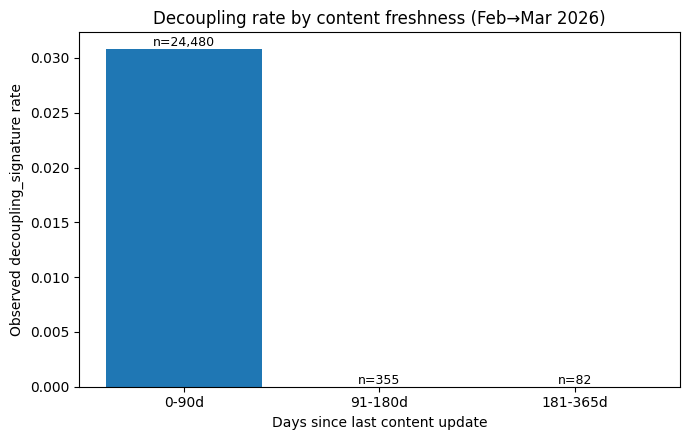

Wrote work/figures/decay_freshness_insight.png


In [9]:
# 3) One figure worth reusing in the paper: decoupling rate by freshness tier (the decay/refresh insight)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(decay_insight['freshness_tier'].astype(str), decay_insight['decoupling_rate'])
for i, row in decay_insight.iterrows():
    ax.text(i, row['decoupling_rate'], f"n={row['n']:,}", ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Days since last content update')
ax.set_ylabel('Observed decoupling_signature rate')
ax.set_title('Decoupling rate by content freshness (Feb\u2192Mar 2026)')
fig.tight_layout()
fig.savefig('work/figures/decay_freshness_insight.png', dpi=150)
plt.show()
print('Wrote work/figures/decay_freshness_insight.png')


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.